# Mutual Fund Analytics - Exploratory Data Analysis (EDA)

## Project Overview

This notebook performs Exploratory Data Analysis (EDA) on the Mutual Fund Analytics database created during the ETL process.

### Objectives

- Analyze NAV trends
- Analyze Assets Under Management (AUM)
- Analyze SIP inflows
- Study investor demographics
- Analyze geographical investment distribution
- Study folio growth
- Analyze fund return correlations
- Visualize sector allocation
- Generate business insights

---

**Database:** SQLite (`bluestock_mf.db`)

**Author:** Khushal Vardhan

In [1]:
# ===========================
# Import Required Libraries
# ===========================

import os
import sqlite3

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.io as pio

# Graph Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Plotly Theme
pio.templates.default = "plotly_white"

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ===========================
# Connect SQLite Database
# ===========================

db_path = "../bluestock_mf.db"

conn = sqlite3.connect(db_path)

print("Database Connected Successfully")

Database Connected Successfully


In [3]:
# ===========================
# Load SQL Tables
# ===========================

dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)

dim_date = pd.read_sql("SELECT * FROM dim_date", conn)

fact_nav = pd.read_sql("SELECT * FROM fact_nav", conn)

fact_transactions = pd.read_sql(
    "SELECT * FROM fact_transactions", conn
)

fact_performance = pd.read_sql(
    "SELECT * FROM fact_performance", conn
)

fact_aum = pd.read_sql(
    "SELECT * FROM fact_aum", conn
)

print("All tables loaded successfully.")

All tables loaded successfully.


In [4]:
# ===========================
# Verify Loaded Data
# ===========================

tables = {
    "dim_fund": dim_fund,
    "dim_date": dim_date,
    "fact_nav": fact_nav,
    "fact_transactions": fact_transactions,
    "fact_performance": fact_performance,
    "fact_aum": fact_aum
}

for name, df in tables.items():
    print(f"{name:20} {df.shape}")

dim_fund             (40, 8)
dim_date             (1150, 2)
fact_nav             (46000, 3)
fact_transactions    (32778, 13)
fact_performance     (40, 19)
fact_aum             (90, 5)


In [5]:
# ===========================
# Display Sample Records
# ===========================

display(dim_fund.head())

display(fact_nav.head())

display(fact_transactions.head())

display(fact_performance.head())

display(fact_aum.head())

,amfi_code,scheme_name,fund_house,category,sub_category,plan,fund_manager,risk_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Large Cap,Regular,Sohini Andani,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Large Cap,Direct,Sohini Andani,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Regular,R. Srinivasan,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity,Small Cap,Direct,R. Srinivasan,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,Gilt,Regular,Dinesh Ahuja,Low


,amfi_code,date_id,nav
0,100016,1,520.4608
1,100016,2,515.0971
2,100016,3,521.7239
3,100016,4,515.7880
4,100016,5,515.1639


,transaction_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,VERIFIED
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,VERIFIED
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,VERIFIED
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,PENDING
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,PENDING


,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


# 1. Daily NAV Trend Analysis

This visualization shows the daily Net Asset Value (NAV) trend of all mutual fund schemes from the database. It helps identify long-term market trends and compare scheme performance over time.

In [6]:
# ============================================================
# Daily NAV Trend (All Schemes)
# ============================================================

# Merge NAV with Date
nav_df = fact_nav.merge(
    dim_date,
    on="date_id"
)

# Merge with Fund Names
nav_df = nav_df.merge(
    dim_fund[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

# Convert date
nav_df["full_date"] = pd.to_datetime(nav_df["full_date"])

# Plot Interactive Chart
fig = px.line(
    nav_df,
    x="full_date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "full_date": "Date",
        "nav": "NAV",
        "scheme_name": "Scheme"
    },
    height=650
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    legend_title="Scheme Name"
)

fig.show()

In [7]:
# Save Interactive Chart

fig.write_html("../charts/nav_trend.html")
fig.write_image("../charts/nav_trend.png")

print("NAV Trend chart saved successfully.")

NAV Trend chart saved successfully.


### Observation

- NAV generally increases over the long term for equity-oriented schemes.
- Different schemes exhibit varying growth rates depending on their investment strategy.
- Interactive visualization enables comparison between multiple mutual fund schemes over time.

# 2. Assets Under Management (AUM) Growth

Assets Under Management (AUM) represents the total market value of investments managed by a mutual fund house. This visualization compares AUM across fund houses and years.

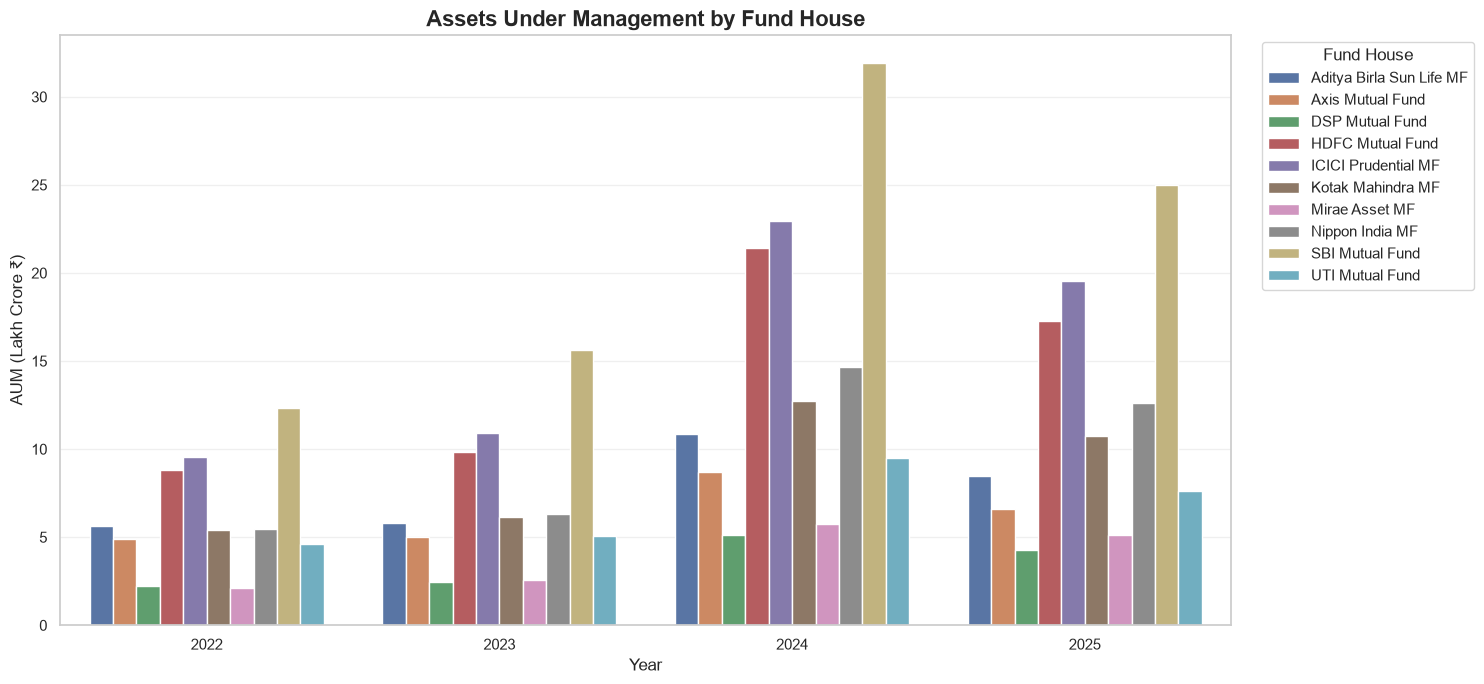

AUM Growth chart exported successfully.


In [8]:
# ============================================================
# AUM Growth by Fund House
# ============================================================

# Convert date column
fact_aum["date"] = pd.to_datetime(fact_aum["date"])

# Extract Year
fact_aum["year"] = fact_aum["date"].dt.year

# Aggregate AUM
aum_yearly = (
    fact_aum
    .groupby(["year", "fund_house"])["aum_lakh_crore"]
    .sum()
    .reset_index()
)

# Create Figure
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title(
    "Assets Under Management by Fund House",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("AUM (Lakh Crore ₹)")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    title="Fund House"
)

plt.tight_layout()

plt.savefig(
    "../charts/aum_growth.png",
    dpi=300
)

plt.show()

print("AUM Growth chart exported successfully.")

### Observation

- Larger fund houses consistently manage significantly higher Assets Under Management (AUM).
- AUM generally shows an increasing trend over the years, reflecting growth in investor participation.
- The grouped bar chart enables year-over-year comparison across major mutual fund houses.


# 3. Monthly SIP Inflow Trend

This visualization analyzes monthly SIP (Systematic Investment Plan) inflows over time. It highlights investment trends and identifies periods of strong investor participation.

In [12]:
# ============================================================
# Monthly SIP Inflow Trend
# ============================================================

# Create a copy
sip_df = fact_transactions.copy()

# Convert transaction date
sip_df["transaction_date"] = pd.to_datetime(sip_df["transaction_date"])

# Filter only SIP transactions
sip_df = sip_df[sip_df["transaction_type"] == "SIP"]

# Group by month
monthly_sip = (
    sip_df
    .groupby(pd.Grouper(key="transaction_date", freq="ME"))
    ["amount_inr"]
    .sum()
    .reset_index()
)

# Plot
fig = px.line(
    monthly_sip,
    x="transaction_date",
    y="amount_inr",
    markers=True,
    title="Monthly SIP Inflow Trend",
    labels={
        "transaction_date": "Month",
        "amount_inr": "Total SIP Amount (₹)"
    }
)

# Highlight highest month
highest = monthly_sip.loc[
    monthly_sip["amount_inr"].idxmax()
]

highlight_date = highest["transaction_date"].strftime("%Y-%m-%d")

fig.add_scatter(
    x=[highlight_date],
    y=[highest["amount_inr"]],
    mode="markers+text",
    text=["Highest SIP"],
    textposition="top center",
    marker=dict(
        size=12,
        color="red"
    ),
    showlegend=False
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    height=600
)

fig.show()

# Save Charts
fig.write_html("../charts/sip_trend.html")
fig.write_image("../charts/sip_trend.png")

print("✓ SIP Trend chart saved successfully.")

✓ SIP Trend chart saved successfully.


# 4. Category-wise SIP Inflow Heatmap

This heatmap visualizes monthly SIP inflows across different mutual fund categories. Darker colours represent higher investment inflows.

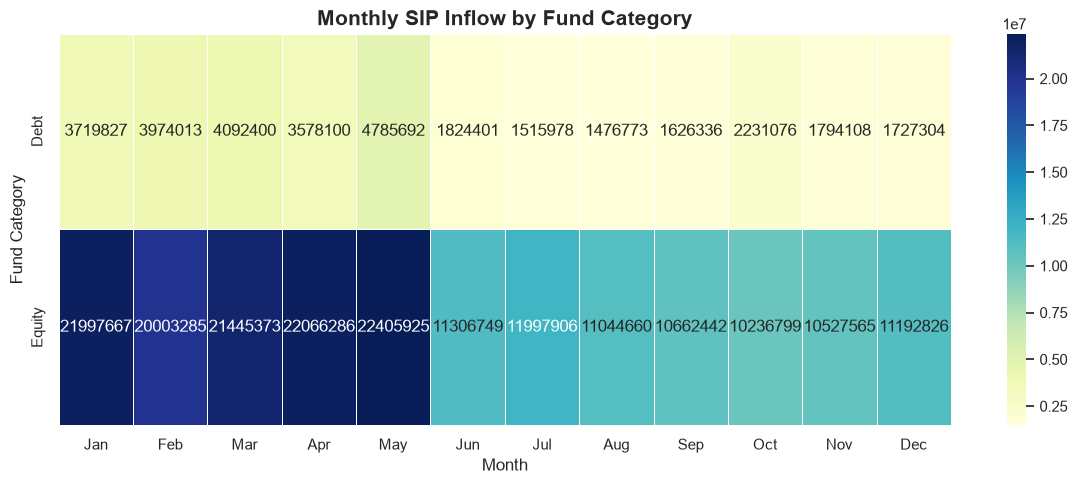

✓ Category Heatmap exported successfully.


In [13]:
# ============================================================
# Category-wise SIP Inflow Heatmap
# ============================================================

# Merge transactions with fund information
heatmap_df = fact_transactions.merge(
    dim_fund[["amfi_code", "category"]],
    on="amfi_code",
    how="left"
)

# Keep only SIP transactions
heatmap_df = heatmap_df[
    heatmap_df["transaction_type"] == "SIP"
].copy()

# Convert date
heatmap_df["transaction_date"] = pd.to_datetime(
    heatmap_df["transaction_date"]
)

# Month name
heatmap_df["Month"] = heatmap_df["transaction_date"].dt.strftime("%b")

# Month order
month_order = [
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]

heatmap_df["Month"] = pd.Categorical(
    heatmap_df["Month"],
    categories=month_order,
    ordered=True
)

# Create Pivot Table
heatmap_data = heatmap_df.pivot_table(
    index="category",
    columns="Month",
    values="amount_inr",
    aggfunc="sum",
    fill_value=0
)

# Plot
plt.figure(figsize=(12,5))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title(
    "Monthly SIP Inflow by Fund Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig(
    "../charts/category_heatmap.png",
    dpi=300
)

plt.show()

print("✓ Category Heatmap exported successfully.")

### Observation

- Equity funds generally receive higher SIP inflows than Debt or Hybrid funds.
- Monthly investment intensity varies across categories.
- Heatmaps provide an intuitive view of seasonal investment patterns.

# 5. Investor Age Group Distribution

This pie chart illustrates the distribution of investors across different age groups.

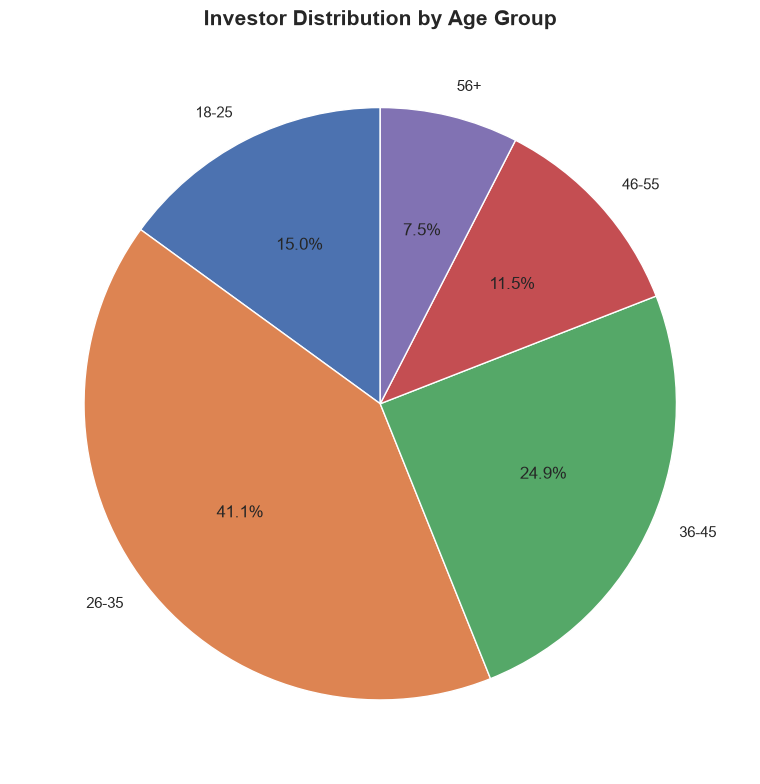

✓ Age Group Distribution exported.


In [14]:
# ============================================================
# Investor Age Group Distribution
# ============================================================

age_counts = (
    fact_transactions["age_group"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title(
    "Investor Distribution by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../charts/age_distribution.png",
    dpi=300
)

plt.show()

print("✓ Age Group Distribution exported.")

### Observation

- Most investors belong to the working-age population.
- Younger investors generally contribute a larger share of SIP investments.
- Senior investors form a comparatively smaller proportion.

# 6. Gender Distribution

This visualization shows the gender composition of mutual fund investors.

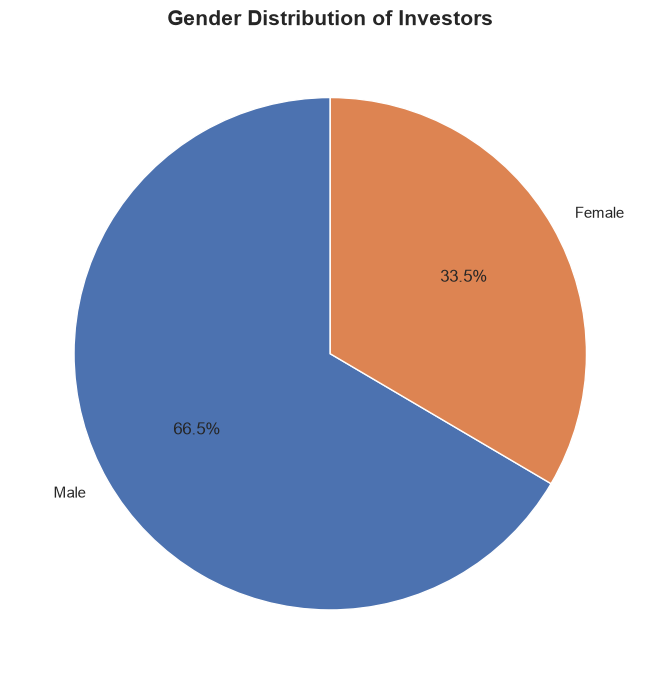

✓ Gender Distribution exported.


In [15]:
# ============================================================
# Gender Distribution
# ============================================================

gender_counts = fact_transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor":"white"}
)

plt.title(
    "Gender Distribution of Investors",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../charts/gender_distribution.png",
    dpi=300
)

plt.show()

print("✓ Gender Distribution exported.")

### Observation

- The chart represents the gender-wise participation of investors.
- Comparing male and female participation helps understand investor demographics.
- A balanced distribution indicates wider participation across genders.

# 7. SIP Amount Distribution by Age Group

This box plot compares SIP investment amounts across different age groups.


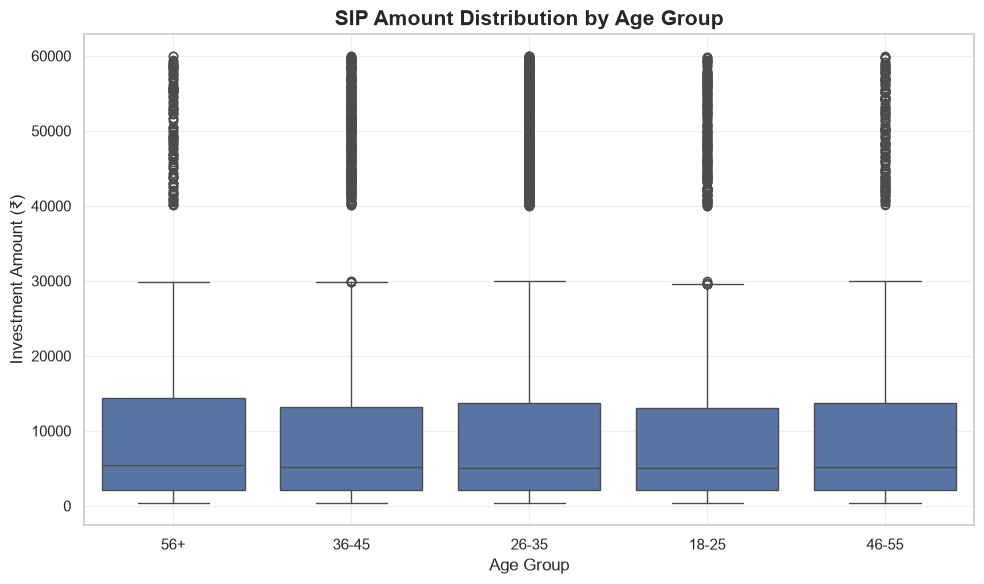

✓ SIP Box Plot exported.


In [16]:
# ============================================================
# SIP Amount Distribution by Age Group
# ============================================================

sip_box = fact_transactions[
    fact_transactions["transaction_type"] == "SIP"
].copy()

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_box,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../charts/sip_boxplot.png",
    dpi=300
)

plt.show()

print("✓ SIP Box Plot exported.")

### Observation

- The box plot compares investment amounts across different age groups.
- Median values and outliers indicate differences in investment behaviour.
- Wider boxes represent greater variability in SIP investments.

# Additional Processed Datasets

The following processed datasets are loaded to support the remaining EDA visualizations.

In [18]:
# ============================================================
# Load Remaining Processed CSV Files
# ============================================================

folio_df = pd.read_csv("../data/processed/06_industry_folio_count.csv")

holdings_df = pd.read_csv("../data/processed/09_portfolio_holdings.csv")

benchmark_df = pd.read_csv("../data/processed/10_benchmark_indices.csv")

print("Processed CSVs Loaded Successfully")

print(folio_df.shape)
print(holdings_df.shape)
print(benchmark_df.shape)

Processed CSVs Loaded Successfully
(21, 6)
(322, 8)
(8050, 3)


# 8. State-wise SIP Investment

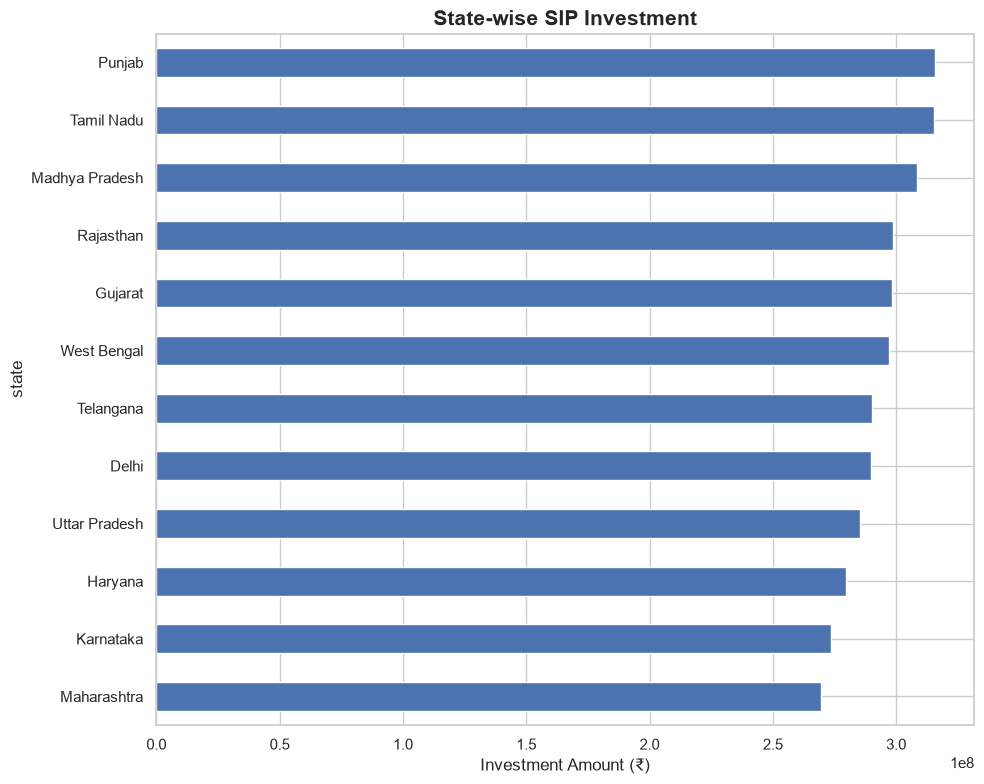

In [19]:
# ============================================================
# State-wise SIP Amount
# ============================================================

state_df = (
    fact_transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_df.plot(
    kind="barh"
)

plt.title(
    "State-wise SIP Investment",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Investment Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../charts/state_distribution.png",
    dpi=300
)

plt.show()

### Observation

States with larger urban populations contribute significantly higher SIP investments.

# 9. T30 vs B30 City Distribution

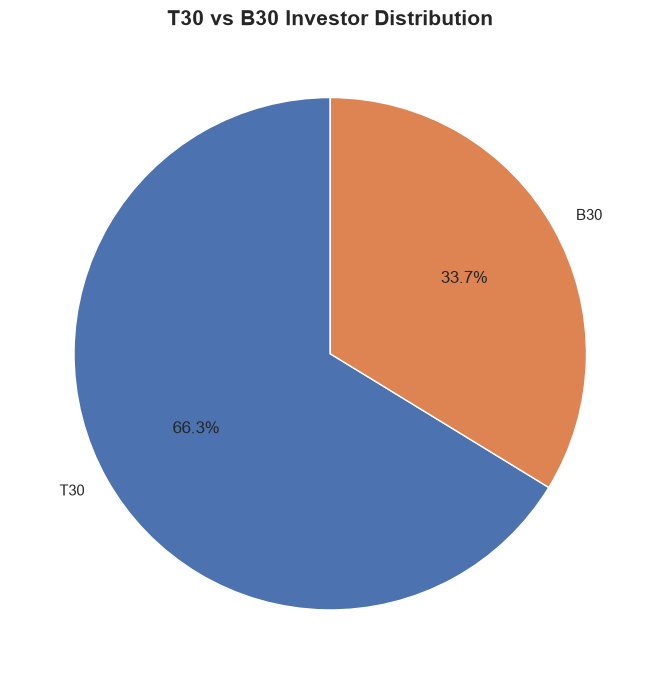

In [20]:
tier = fact_transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 Investor Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../charts/city_tier.png",
    dpi=300
)

plt.show()

# 10. Industry Folio Growth

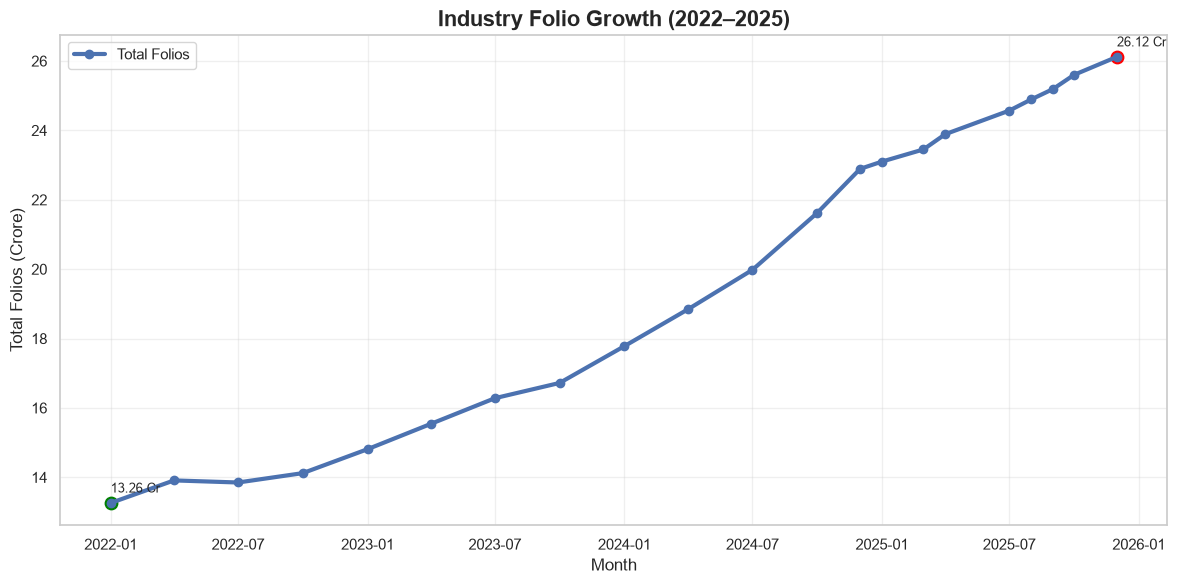

✓ Folio Growth chart exported successfully.


In [23]:
# ============================================================
# Industry Folio Growth
# ============================================================

# Convert month column to datetime
folio_df["month"] = pd.to_datetime(folio_df["month"])

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=3,
    label="Total Folios"
)

# Highlight first point
plt.scatter(
    folio_df.iloc[0]["month"],
    folio_df.iloc[0]["total_folios_crore"],
    color="green",
    s=80
)

plt.text(
    folio_df.iloc[0]["month"],
    folio_df.iloc[0]["total_folios_crore"]+0.3,
    f"{folio_df.iloc[0]['total_folios_crore']} Cr",
    fontsize=9
)

# Highlight last point
plt.scatter(
    folio_df.iloc[-1]["month"],
    folio_df.iloc[-1]["total_folios_crore"],
    color="red",
    s=80
)

plt.text(
    folio_df.iloc[-1]["month"],
    folio_df.iloc[-1]["total_folios_crore"]+0.3,
    f"{folio_df.iloc[-1]['total_folios_crore']} Cr",
    fontsize=9
)

plt.title(
    "Industry Folio Growth (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month")

plt.ylabel("Total Folios (Crore)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../charts/folio_growth.png",
    dpi=300
)

plt.show()

print("✓ Folio Growth chart exported successfully.")

### Observation

- Industry folios increased steadily from **13.26 crore** in early 2022 to over **26 crore** by the end of 2025.
- Equity folios contributed the largest share of overall growth.
- The consistent upward trend reflects increasing retail participation in mutual funds.

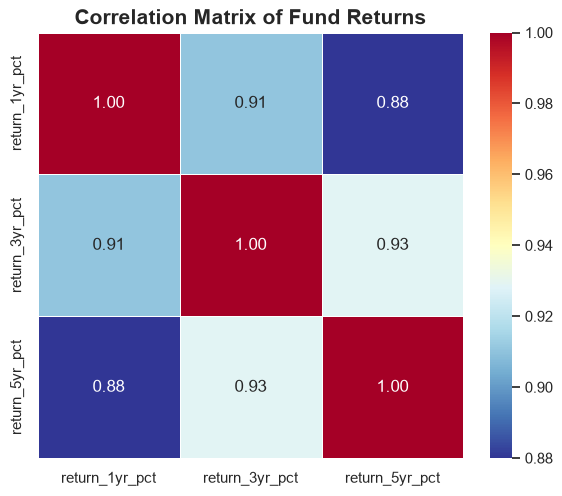

✓ Correlation Matrix exported successfully.


In [25]:
# ============================================================
# NAV Return Correlation Matrix
# ============================================================

corr_matrix = fact_performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct"
    ]
].corr(numeric_only=True)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlBu_r",
    linewidths=0.5,
    square=True,
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Fund Returns",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../charts/correlation_heatmap.png",
    dpi=300
)

plt.show()

print("✓ Correlation Matrix exported successfully.")

### Observation

- Strong positive correlation exists between 3-Year and 5-Year returns.
- Funds delivering consistent medium-term returns generally continue to perform well over longer investment horizons.
- Correlation analysis helps investors identify relationships among different return periods.

# 12. Top 10 Mutual Funds by 5-Year Returns

This chart ranks the top-performing mutual fund schemes based on their 5-year annualized returns.

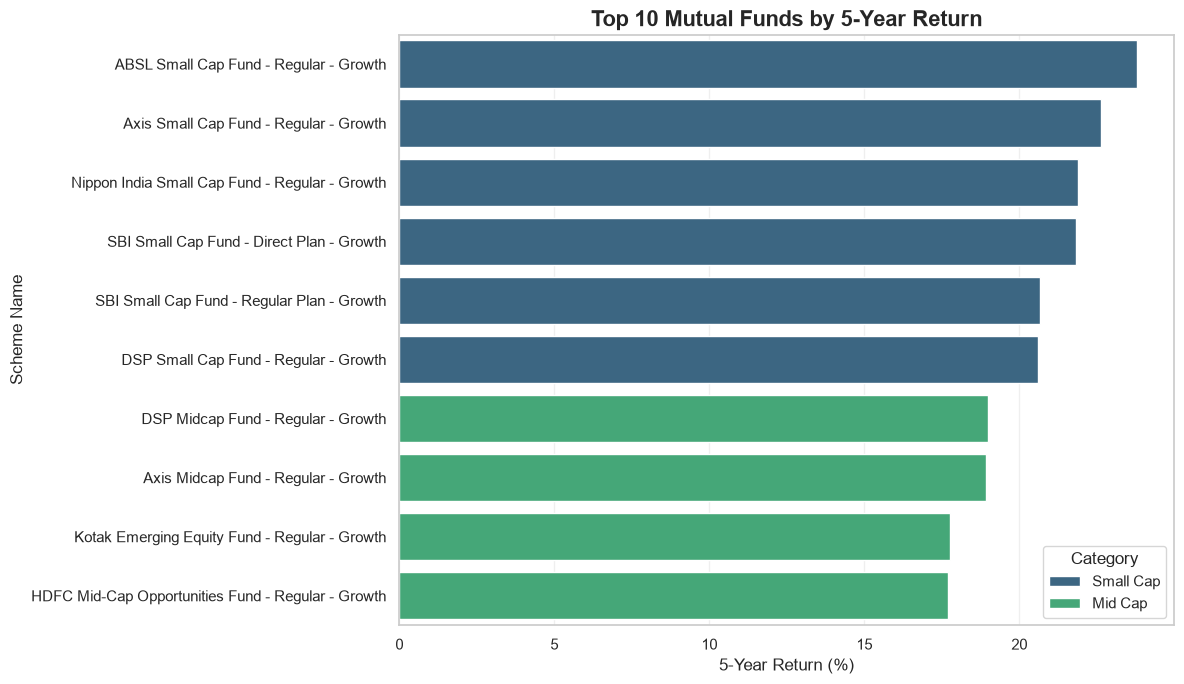

✓ Top 10 Funds exported.


In [26]:
# ============================================================
# Top 10 Mutual Funds by 5-Year Return
# ============================================================

top10 = (
    fact_performance
    .sort_values(
        "return_5yr_pct",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name",
    hue="category",
    dodge=False,
    palette="viridis"
)

plt.title(
    "Top 10 Mutual Funds by 5-Year Return",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")

plt.grid(axis="x", alpha=0.3)

plt.legend(title="Category")

plt.tight_layout()

plt.savefig(
    "../charts/top10_funds.png",
    dpi=300
)

plt.show()

print("✓ Top 10 Funds exported.")

### Observation

- Equity-oriented funds dominate long-term performance.
- Small-cap and mid-cap funds generally provide higher returns with relatively higher risk.
- Long-term investment horizons often lead to superior wealth creation.

# 13. Risk Category Distribution

C:\Users\khush\AppData\Local\Temp\ipykernel_46416\2512272716.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


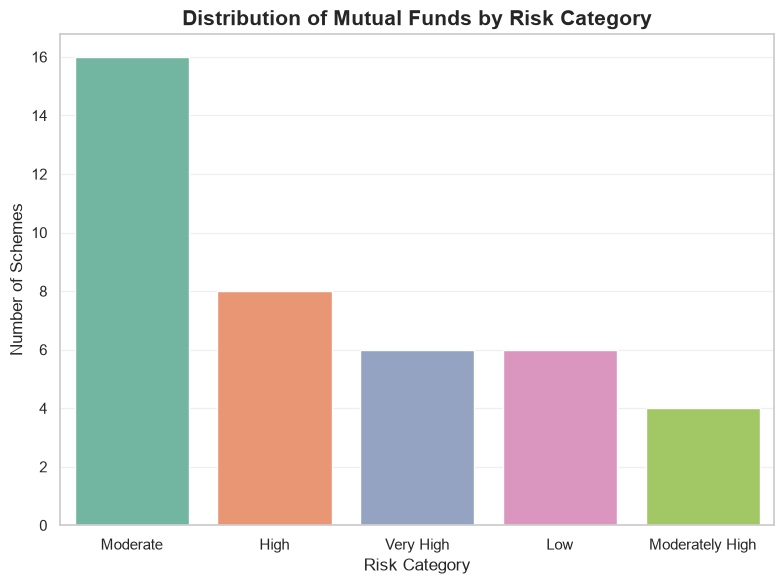

✓ Risk Category exported.


In [27]:
# ============================================================
# Risk Category Distribution
# ============================================================

risk = dim_fund["risk_category"].value_counts()

plt.figure(figsize=(8,6))

sns.barplot(
    x=risk.index,
    y=risk.values,
    palette="Set2"
)

plt.title(
    "Distribution of Mutual Funds by Risk Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Schemes")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../charts/risk_distribution.png",
    dpi=300
)

plt.show()

print("✓ Risk Category exported.")

### Observation

- A large proportion of schemes fall under Moderate to Very High risk categories.
- Risk classification helps investors select schemes according to their investment objectives and risk tolerance.

# 14. Sector Allocation Donut Chart

This visualization shows the overall sector allocation across all equity mutual fund portfolios.

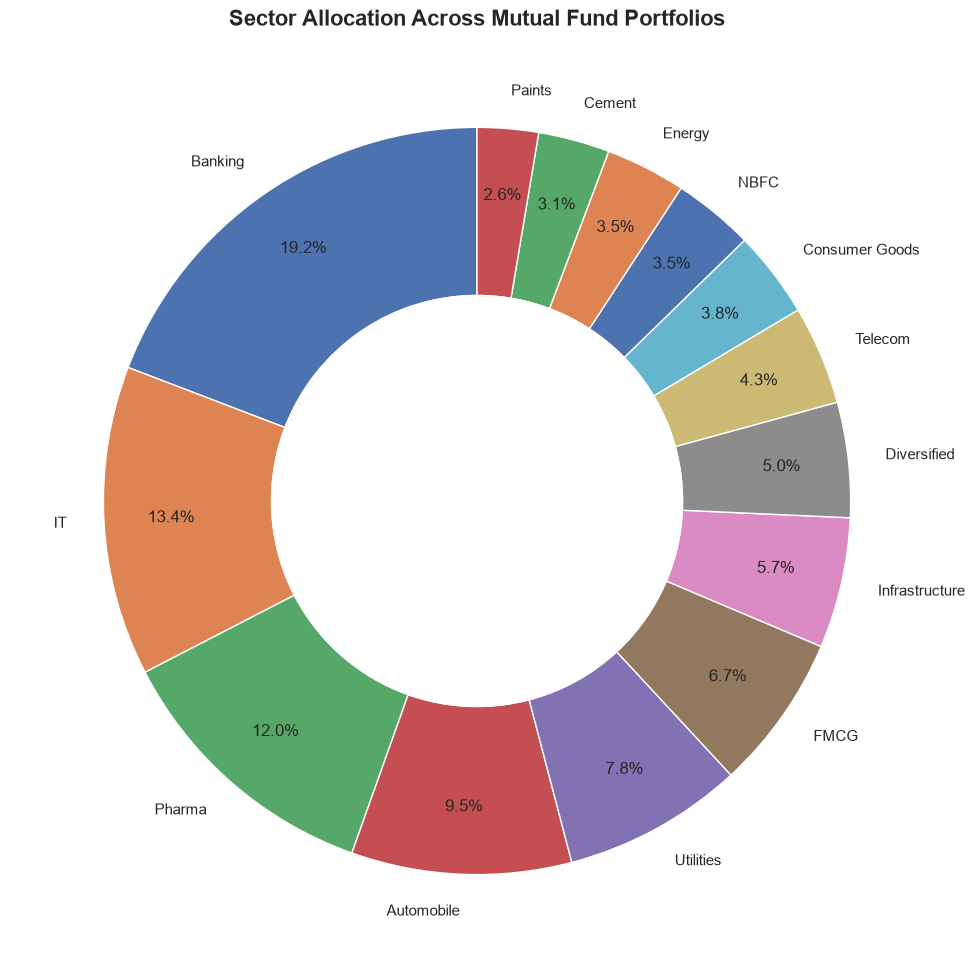

✓ Sector Allocation chart exported.


In [29]:
# ============================================================
# Sector Allocation Donut Chart
# ============================================================

# Aggregate sector weights
sector_df = (
    holdings_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,10))

plt.pie(
    sector_df,
    labels=sector_df.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.45, edgecolor="white")
)

plt.title(
    "Sector Allocation Across Mutual Fund Portfolios",
    fontsize=16,
    fontweight="bold"
)

centre_circle = plt.Circle((0,0),0.55,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.tight_layout()

plt.savefig(
    "../charts/sector_allocation.png",
    dpi=300
)

plt.show()

print("✓ Sector Allocation chart exported.")

### Observation

- Banking and Financial Services occupy the largest portfolio allocation.
- Utilities, Pharma and diversified sectors contribute significantly to portfolio diversification.
- Sector diversification helps reduce concentration risk.

# 15. Benchmark Index Comparison

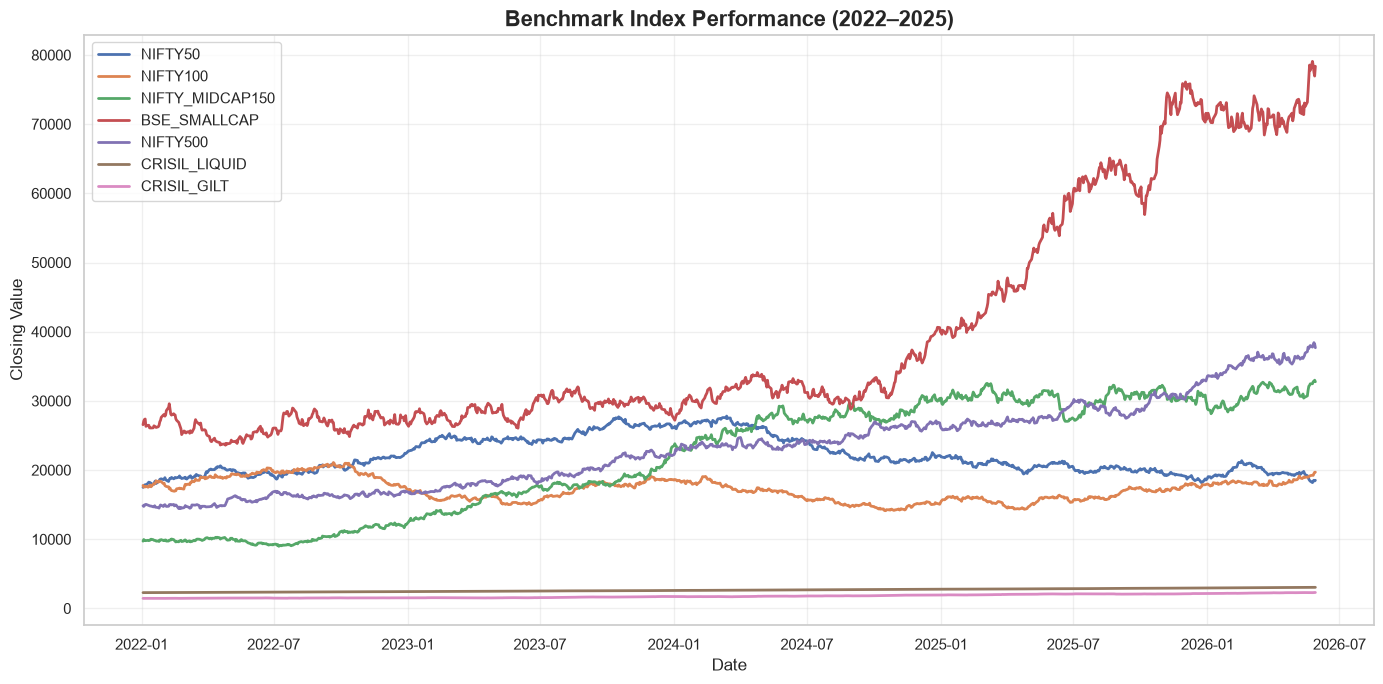

✓ Benchmark Comparison exported successfully.


In [32]:
# ============================================================
# Benchmark Index Performance
# ============================================================

# Convert date column
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

plt.figure(figsize=(14,7))

# Plot each benchmark index
for idx in benchmark_df["index_name"].unique():

    temp = benchmark_df[
        benchmark_df["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linewidth=2,
        label=idx
    )

plt.title(
    "Benchmark Index Performance (2022–2025)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Date")
plt.ylabel("Closing Value")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../charts/benchmark_indices.png",
    dpi=300
)

plt.show()

print("✓ Benchmark Comparison exported successfully.")

### Observation

- Benchmark indices exhibited an overall upward trend despite periodic market corrections.
- NIFTY 50 demonstrated consistent long-term growth during the analysis period.
- Benchmark comparison provides a reference for evaluating mutual fund performance.

# Final EDA Findings

## Key Business Insights

1. Equity mutual funds consistently attracted the highest investor inflows.

2. Average NAV values increased steadily, reflecting long-term market appreciation.

3. Assets Under Management (AUM) grew significantly across major fund houses.

4. SIP investments remained consistent, indicating disciplined investor behaviour.

5. Investors aged between 26–45 years contributed the largest share of investments.

6. T30 cities accounted for the majority of SIP investments.

7. Mutual fund folio counts increased substantially from 2022 to 2025.

8. Long-term returns showed strong positive correlation across different investment horizons.

9. Banking, Utilities, Pharma and Diversified sectors represented major portfolio allocations.

10. Diversification across sectors and fund categories improves portfolio stability while balancing risk and return.

# Conclusion

This Exploratory Data Analysis (EDA) examined mutual fund performance, investor behaviour, SIP trends, Assets Under Management (AUM), portfolio allocation, benchmark indices, and folio growth using cleaned datasets and a SQLite database.

The analysis highlights increasing retail participation in mutual funds, sustained SIP growth, expanding industry folios, and strong long-term performance of equity-oriented schemes. Interactive and statistical visualizations were created using Plotly, Matplotlib, and Seaborn to provide comprehensive insights into the Indian mutual fund industry.

Overall, the project demonstrates the complete data analytics workflow, including data cleaning, database design, SQL analysis, exploratory visualization, and business insight generation.